In [13]:
from lib.utils import *

# Importing audio files

In [14]:
from pathlib import Path
import pandas as pd
from pandas import Timestamp
from datetime import datetime
import re

def parse_filename_datetime(filename):
    """
    Extracts the start timestamp from a WAV filename using regex.

    Args:
        filename (str): The name of the file (e.g., '2020_05_01_10_00_00_000000.wav').

    Returns:
        Timestamp: A pandas Timestamp object representing the start of the recording.
    """
    match = timestamp_pattern.search(filename)
    date_part, time_part = match.groups()
    time_elements = time_part.split('_')
    time_str = f"{time_elements[0]}:{time_elements[1]}:{time_elements[2]}"
    dt_str = f"{date_part.replace('_', '-')} {time_str}"

    return Timestamp(datetime.strptime(dt_str, "%Y-%m-%d %H:%M:%S"))

# Define the source directory containing the acoustic data
folder = Path(r"data")

# Regex pattern to extract date (YYYY_MM_DD) and time (HH_MM_SS) from filenames
timestamp_pattern = re.compile(r"(\d{4}_\d{2}_\d{2})_(\d{2}_\d{2}_\d{2})_000000")

# Retrieve all WAV files and instantiate AudioFile objects for each file
files = list(folder.glob("*.wav"))
audio_files = [
    AudioFile(path=path, begin=parse_filename_datetime(path.name))
    for path in files
]

In [15]:
# Define the temporal boundaries for data extraction
begin_date = Timestamp("2020-06-04 00:00:00")
end_date = Timestamp("2020-06-12 00:00:00")

# Load the acoustic data from the provided list of AudioFile objects
# This filters and concatenates the relevant audio segments within the date range
audio_data = AudioData.from_files(
    files=audio_files,
    begin=begin_date,
    end=end_date
)

print(f"Sample rate : {audio_data.sample_rate}")
print(f"Duration : {audio_data.duration}")

Sample rate : 240
Duration : 8 days 00:00:00


# Detection of 20 Hz fin whale calls

Note: the parameters depend on the characteristics of fine whales calls. Here we are detecting 20 Hz fin whale calls with 15s inter-call interval.

In [16]:
# Minimum and maximum frequency limits for 20Hz calls
F_MIN = 18
F_MAX = 22

In [17]:
# Initialize empty lists to store concatenated results
all_frequencies = []
all_times = []
all_spectrograms = []

# FFT parameters
FFT_SIZE = 1024
OVERLAP = 0.95
INTEGRATION = 5

# Compute the longterm cepstrogram on a daily basis and concatenate the results
t, q, c = compute_longterm_cepstro(audio_files, begin_date, end_date, FFT_SIZE, F_MIN, F_MAX)

Day processed = 2020-06-04 00:00:00
Day processed = 2020-06-05 00:00:00
Day processed = 2020-06-06 00:00:00
Day processed = 2020-06-07 00:00:00
Day processed = 2020-06-08 00:00:00
Day processed = 2020-06-09 00:00:00
Day processed = 2020-06-10 00:00:00
Day processed = 2020-06-11 00:00:00


In [18]:
# To adapt to the metric DPH, we compute the mean cepstrum on an hourly basis and concatenate the results
c_hourly, t_hourly = compute_mean_cepstrum(t, c, q, begin_date, end_date)

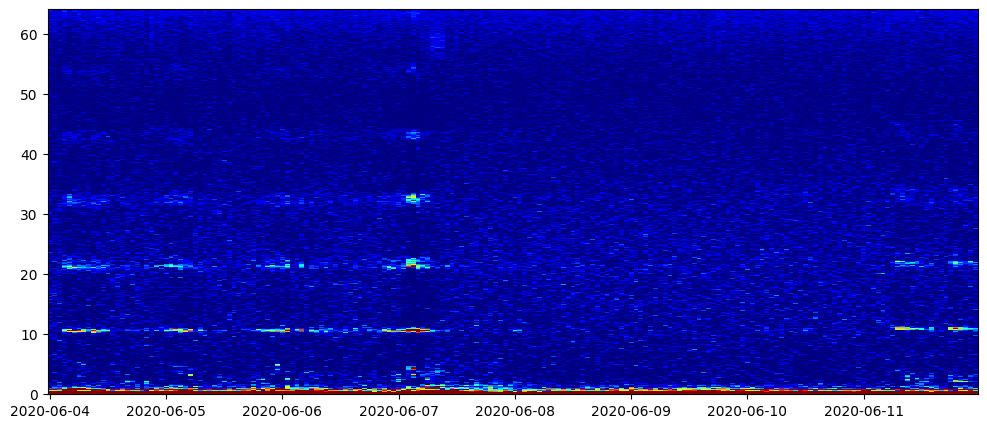

In [19]:
import matplotlib.pyplot as plt

# P2VR parameters
PEAK_BOUNDARIES = [14.5, 17]
VALLEY_BOUNDARIES = [12., 19.5]

# plot the cepstrogram
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_hourly,q,c_hourly, vmin=0, vmax=0.02, cmap='jet')
plt.show()

In [20]:
WINDOW_SIZE = 6

# Compute the peak to valley ratio for the mean cepstrum
p2vr = compute_p2vr(c_hourly, q, PEAK_BOUNDARIES, VALLEY_BOUNDARIES, WINDOW_SIZE)


In [21]:
# Apply a THRESHOLD to the peak to valley ratio to detect positive detections
THRESHOLD = 0.5
above_THRESHOLD_indices = np.where(p2vr > THRESHOLD)[0]

positive_detection = np.zeros_like(p2vr, dtype=int)
positive_detection[above_THRESHOLD_indices] = 1

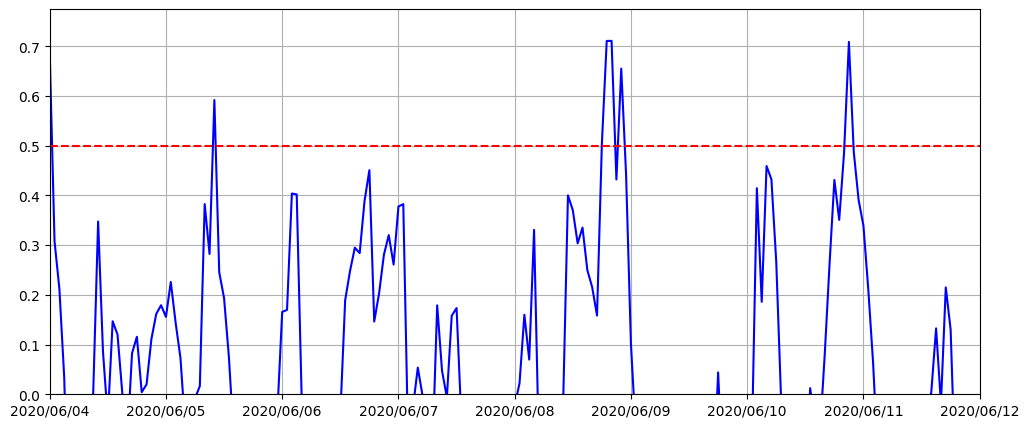

In [22]:
# Plot the peak to valley ratio
plt.figure(figsize=(12, 5))
ax=plt.subplot()
ax.plot(t_hourly, p2vr, color='blue', label='p2vr')
ax.grid()
ax.set_ylim(0,)
ax.set_xlim(begin_date,end_date)

plt.plot([begin_date, end_date], [THRESHOLD,THRESHOLD], 'r--')

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))
plt.show()

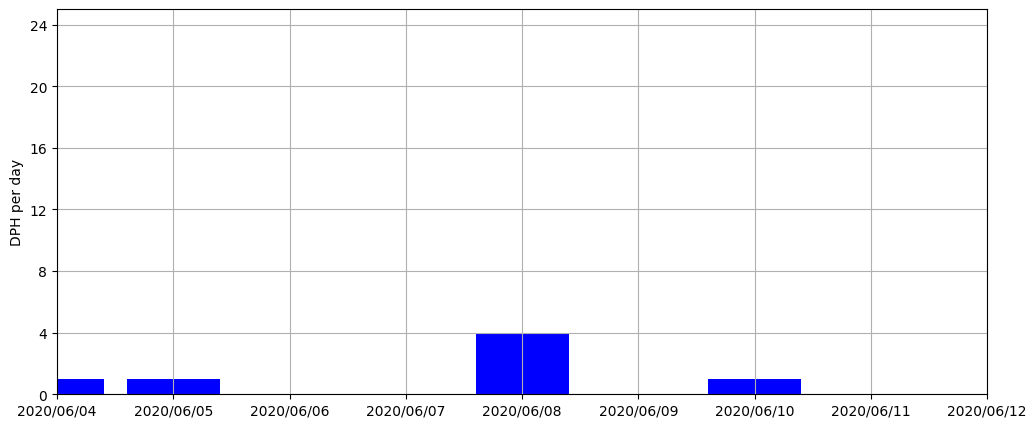

In [23]:
# Compute the DPH per day by resampling the positive detections on an hourly basis and summing them up on a daily basis
resampled_positive = pd.Series(positive_detection).groupby(pd.to_datetime(t_hourly).floor("1h")).sum()
daily_positive_hours = resampled_positive.groupby(resampled_positive.index.date).sum()

# Plot the DPH per day
plt.figure(figsize=(12, 5))
ax3 = plt.subplot(1, 1, 1)
ax3.bar(daily_positive_hours.index, daily_positive_hours.values, color='blue')
ax3.set_ylim(0,25)
ax3.set_yticks(range(0, 25, 4))
ax3.set_xlim(begin_date,end_date)
ax3.grid()
ax3.set_ylabel('DPH per day')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))
plt.show()

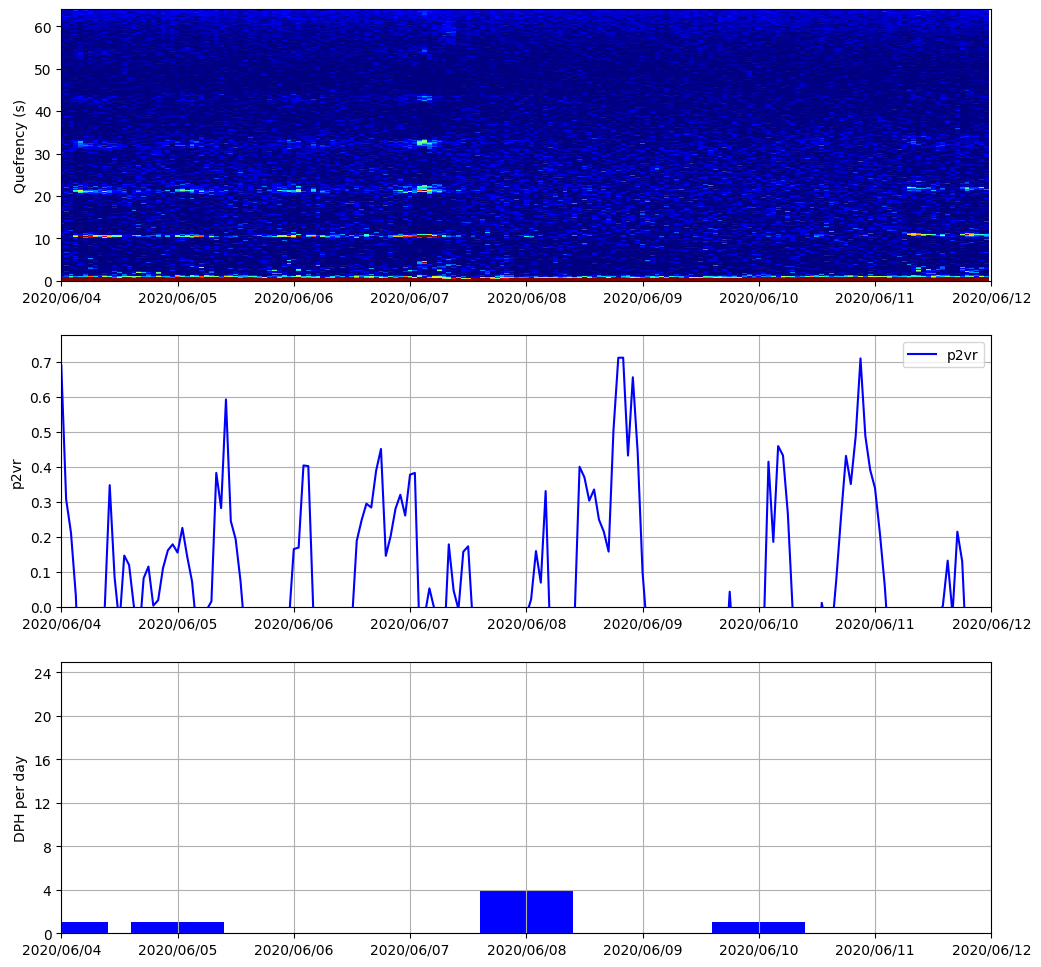

In [24]:
plt.figure(figsize=(12, 12))
ax1 = plt.subplot(3, 1, 1)
ax1.pcolormesh(t_hourly,q,c_hourly, vmin=0, vmax=0.02, cmap='jet')
ax1.set_xlim(begin_date,end_date)
ax1.set_ylabel('Quefrency (s)')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))

ax2 = plt.subplot(3, 1, 2)
ax2.plot(t_hourly, p2vr, color='blue', label='p2vr')
ax2.grid()
ax2.set_ylim(0,)
ax2.set_xlim(begin_date,end_date)
ax2.set_ylabel('p2vr')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))

ax3 = plt.subplot(3, 1, 3)
ax3.bar(daily_positive_hours.index, daily_positive_hours.values, color='blue')
ax3.set_ylim(0,25)
ax3.set_yticks(range(0, 25, 4))
ax3.set_xlim(begin_date,end_date)
ax3.grid()
ax3.set_ylabel('DPH per day')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))

plt.show()